# Machine Learners IST 707 Project Checkpoint

--------------------------------------

## Transparent ESG Prediction: Machine Learning for Accessible Corporate Sustainability Assessment

--------------------------------------

### Team Members

**Point of Contact (POC):** Ethan Radecki (GitHubID: 244611837)

**Team Members:**

- Caden Lippie (GitHubID: 155611281)
- John Masseria (GitHubID: 194737462)
- Ethan Radecki (GitHubID: 244611837)

Ethan Radecki will manage the repository and serve as the primary contact for project submissions.

## Overview

**What are we trying to do?**  
We are building a machine learning system that predicts corporate ESG (Environmental, Social, and Governance) scores using only free public documents. All U.S. public companies must file annual 10-K reports with the SEC. We extract text from these filings and use a finance-specific language model (FinBERT) to generate features that predict whether a company is a strong or weak ESG performer — without requiring expensive proprietary ratings that cost $5,000–$30,000+ per year.

**What is new and why will it succeed?**  
We use only free public data (SEC EDGAR 10-K filings), removing cost barriers entirely. We combine FinBERT sentiment analysis of ESG-relevant text with interpretable ML (SHAP values) to explain why a company receives a given score which addresses the "black box" problem of commercial ratings. Prior research shows BERT-based models can achieve over 80% accuracy on ESG classification from text, and FinBERT's finance-specific pre-training gives it an advantage over general-purpose NLP models for this domain.

**Who cares?**  
The global ESG asset market exceeds $30 trillion. Our primary stakeholders are retail investors who want values-aligned portfolios but cannot afford institutional data subscriptions, and small/mid-cap companies that currently lack ESG ratings and remain invisible to sustainability-focused capital. A free, transparent prediction system democratizes access and provides actionable guidance to both groups.

*These objectives are unchanged from our proposal submission.*

## Data

In [10]:
%%capture
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

ESG_PATH        = '../data/ESG_data_cleaned.csv'
FEATURES_PATH   = '../data/finbert_features/merged_features_labels.csv'
IMPORTANCE_PATH = '../data/finbert_features/feature_importance.csv'

df_esg  = pd.read_csv(ESG_PATH)
df_feat = pd.read_csv(FEATURES_PATH)
df_imp  = pd.read_csv(IMPORTANCE_PATH)

SCORE_COLS = ['environment_score', 'social_score', 'governance_score', 'total_score']
COLORS     = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

### Data Sources and Provenance

We use two primary datasets linked by company CIK identifiers:

1. **Public Company ESG Ratings Dataset** ([Kaggle, A. King, 2024](https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset)): ESG ratings for 722 mid-to-large cap U.S.-listed companies updated throughout 2022. Each record includes numerical ESG scores across three pillars plus an overall total, along with letter grades and industry classifications. All 709 non-SPAC companies have valid SEC CIK identifiers enabling direct linkage to EDGAR filings. The dataset is entirely U.S.-centric (NYSE and NASDAQ only, 97% USD-denominated) — both a strength (consistent regulatory environment and disclosure requirements) and a limitation (no international coverage).

2. **SEC 10-K Annual Filings** (via [`sec-edgar-downloader`](https://github.com/jadchaar/sec-edgar-downloader), free public access from [SEC EDGAR](https://www.sec.gov/)): The most recent 10-K filed before April 2022 for each company, ensuring temporal alignment with the ESG ratings. These are primary government disclosures subject to strict SEC standards, making them highly credible and standardized.

**Provenance validation:** We confirmed (1) 100% CIK linkage coverage to EDGAR, (2) consistent score ranges across pillars with no impossible values, (3) plausible industry distributions matching known U.S. equity market composition, and (4) logical alignment between letter grades and underlying numeric scores.

### ESG Score Distributions

We first examine the distributions of the four numeric ESG score columns. Understanding distribution shape informs our choice of targets and loss functions for modeling.

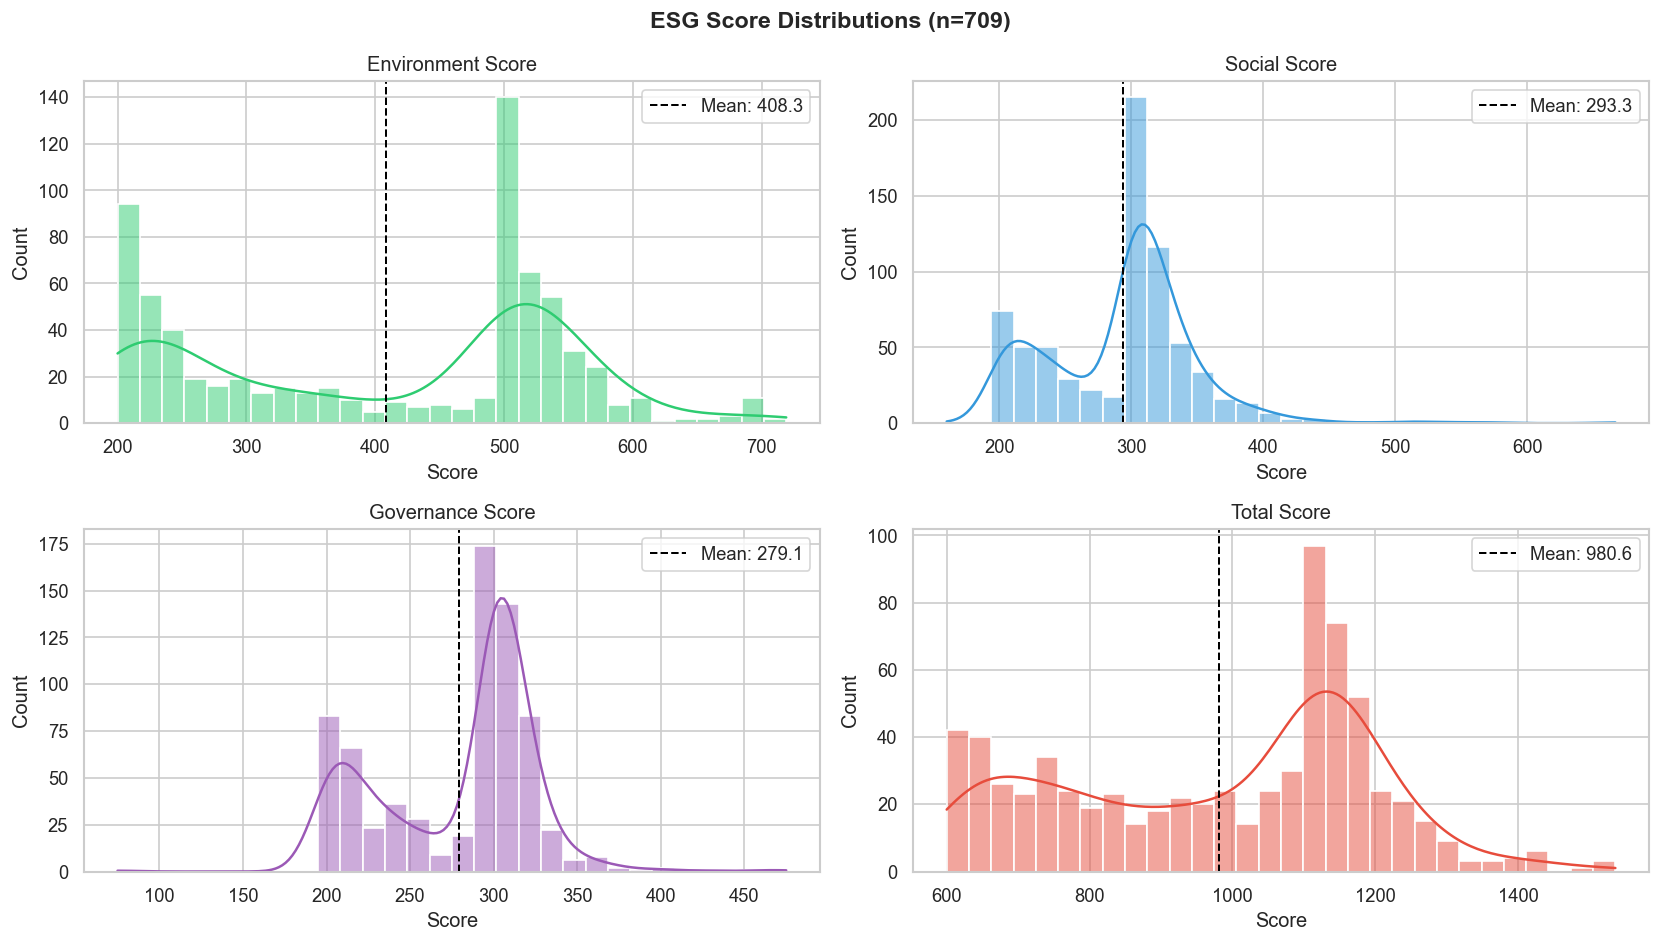

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, color in zip(axes.flatten(), SCORE_COLS, COLORS):
    sns.histplot(df_esg[col].dropna(), bins=30, kde=True, ax=ax, color=color)
    ax.axvline(df_esg[col].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {df_esg[col].mean():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Score')
    ax.legend()
plt.suptitle('ESG Score Distributions (n=709)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The **Environment Score** is strikingly **bimodal**, with two distinct clusters around 200–250 and 500–520 which suggests two populations of companies (low and high environmental performers) with few in between. The **Social Score** is right-skewed with most companies tightly clustered around 280–320. The **Governance Score** is approximately normal with the narrowest spread (std ≈ 47), suggesting companies converge on governance practices more uniformly than environmental ones. The **Total Score** inherits the bimodality from Environment Score, which we show below has a 0.96 correlation with the total rating.

### Industry-Level ESG Performance

The environment score's bimodal shape suggests it may be driven by industry composition. We plot mean ESG scores across the 15 most-represented industries to test this hypothesis.

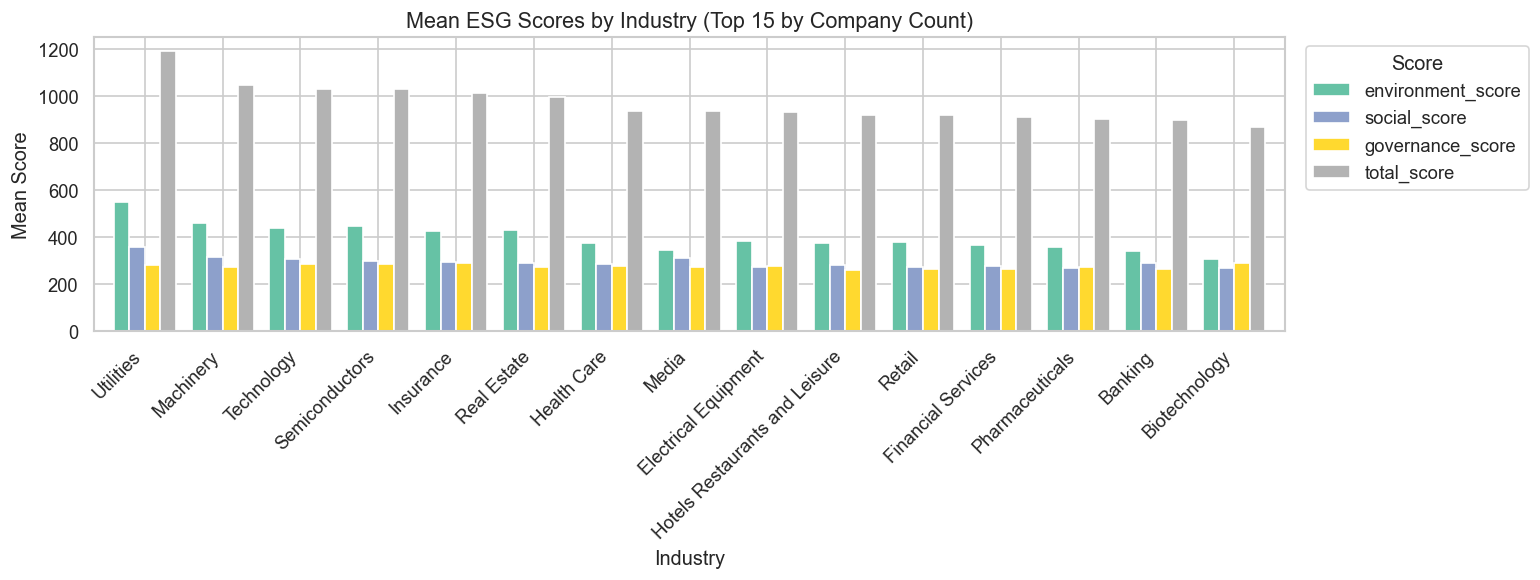

In [12]:
top_inds = df_esg['industry'].value_counts().head(15).index.tolist()
ind_scores = (
    df_esg[df_esg['industry'].isin(top_inds)]
    .groupby('industry')[SCORE_COLS]
    .mean()
    .sort_values('total_score', ascending=False)
)
fig, ax = plt.subplots(figsize=(13, 5))
ind_scores.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.8)
ax.set_title('Mean ESG Scores by Industry (Top 15 by Company Count)', fontsize=13)
ax.set_ylabel('Mean Score')
ax.set_xlabel('Industry')
ax.legend(title='Score', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Utilities** leads in environment score (mean ≈ 551) and total score, consistent with heavy regulatory pressure on energy infrastructure companies. **Biotechnology** , the second most-represented industry, ranks last among the top 15 in environment score (mean ≈ 307), despite strong social and governance scores. Social and governance scores are far more uniform across industries (most in the 260–360 range). This confirms that **industry type is the primary driver of environment score variation**, explaining the bimodal distribution observed above and making industry a critical feature to include in modeling.

### Pillar Correlations

To understand which ESG pillar most strongly drives the overall rating, we compute pairwise Pearson correlations between all four score columns.

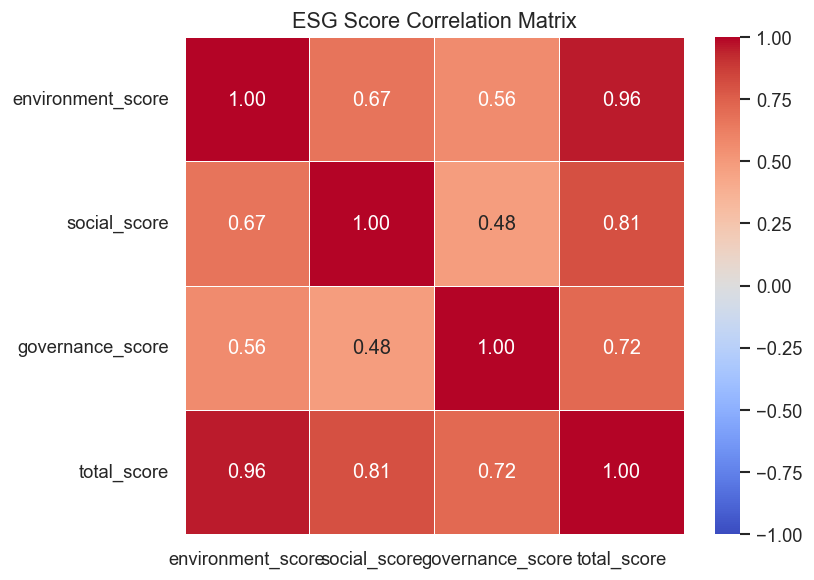

In [13]:
corr = df_esg[SCORE_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('ESG Score Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

The **Environment Score** has a **0.96 correlation with Total Score** and is overwhelmingly the dominant pillar. Social (0.81) and Governance (0.72) contribute less and vary more independently of one another (correlation = 0.48). This has direct implications for feature engineering: FinBERT features that capture environmental disclosure quality will be most predictive of the total rating, while social and governance predictions will require more targeted feature sets.

### Dimensionality Reduction: PCA of FinBERT Features

To explore whether the 76 FinBERT features extracted from 10-K filings contain separable structure by ESG grade, we apply PCA and visualize the first two principal components colored by total grade. This helps us assess whether the feature space carries sufficient signal before modeling.

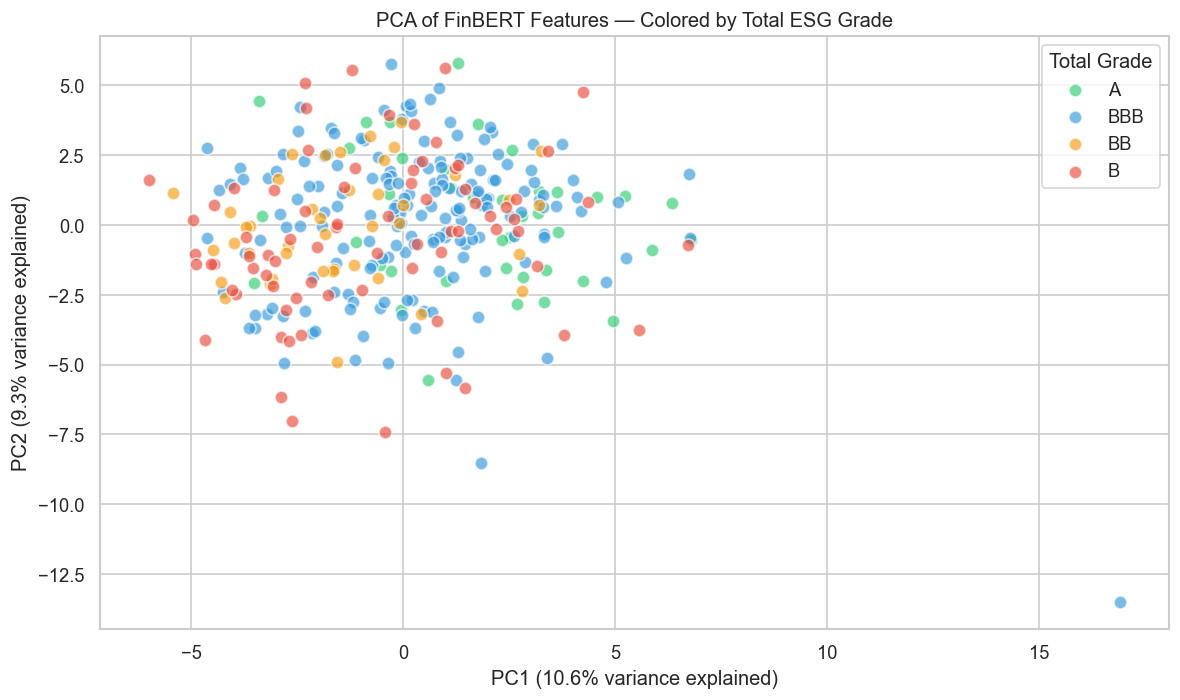

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

exclude = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade']
feature_cols = [c for c in df_feat.columns if c not in exclude]

X_pca = df_feat[feature_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({'PC1': X_2d[:, 0], 'PC2': X_2d[:, 1],
                        'Grade': df_feat['total_grade']})

palette = {'A': '#2ecc71', 'BBB': '#3498db', 'BB': '#f39c12', 'B': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 6))
for grade in ['A', 'BBB', 'BB', 'B']:
    sub = pca_df[pca_df['Grade'] == grade]
    ax.scatter(sub['PC1'], sub['PC2'], label=grade,
               color=palette[grade], alpha=0.65, edgecolors='white', s=60)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')
ax.set_title('PCA of FinBERT Features — Colored by Total ESG Grade', fontsize=12)
ax.legend(title='Total Grade')
plt.tight_layout()
plt.show()

The PCA reveals **partial separation by ESG grade along PC1**, with Grade A companies (green) tending toward higher PC1 values and Grade B companies (red) toward lower values. The separation is imperfect, grades overlap substantially, indicating that while the FinBERT features capture some ESG-relevant signal, they do not cleanly separate all grade categories in two dimensions. This is consistent with our modeling results and motivates additional feature engineering, particularly the addition of industry as an explicit feature.

### Additional EDA Findings

**Outliers:** Using the IQR method, we identified only 12 outlier companies (1.7%), all high performers with exceptional environment scores (e.g., Microsoft: 715, ConocoPhillips: 687, Air Products: 700). These represent genuine performance extremes rather than data errors and are retained for modeling.

**Temporal coverage:** All 709 ratings were processed in 2022 (concentrated in April and June), confirming the dataset is a **cross-sectional snapshot** rather than a longitudinal record. Our models predict ESG scores at a single point in time.

**Dataset composition:** 100% NYSE or NASDAQ, 97% USD-denominated. Technology (63), Biotechnology (56), and Health Care (51) are the three most-represented industries, introducing sampling bias toward knowledge-based sectors. We will use stratified train/test splits to mitigate this in modeling.

## Preprocessing

### Step 1: Remove SPACs

The raw ESG dataset contains 13 Special Purpose Acquisition Companies (SPACs), which have no real business operations. Their ESG scores are unreliable and their `industry` field is missing, making them unsuitable for any industry-based analysis or modeling. We identify and remove them by their null `industry` label.

In [15]:
%%capture
df_raw = pd.read_csv('../data/ESG_data.csv')
df_raw.drop(columns=['logo', 'weburl'], inplace=True, errors='ignore')

In [16]:
spac_count = df_raw['industry'].isna().sum()
print(f'Raw dataset:      {len(df_raw):,} companies')
print(f'SPACs removed:    {spac_count:,}  (no industry label, unreliable ESG scores)')
print(f'Cleaned dataset:  {len(df_raw) - spac_count:,} companies')

Raw dataset:      722 companies
SPACs removed:    13  (no industry label, unreliable ESG scores)
Cleaned dataset:  709 companies


### Step 2: Standardize Industry Labels

Manual inspection revealed four industry label inconsistencies caused by formatting differences (ampersands vs. spelled-out "and", trailing whitespace). We merge these to avoid duplicate categories that would distort industry distributions and one-hot encoding downstream.

In [17]:
INDUSTRY_MAP = {
    'Hotels, Restaurants & Leisure': 'Hotels Restaurants and Leisure',
    'Metals & Mining':               'Metals and Mining',
    'Aerospace & Defense':           'Aerospace and Defense',
    'Energy ':                       'Energy',  # trailing whitespace
}

df_clean = df_raw.dropna(subset=['industry']).copy()
before = df_clean['industry'].nunique()
df_clean['industry'] = df_clean['industry'].replace(INDUSTRY_MAP)
after  = df_clean['industry'].nunique()

print(f'Unique industries before standardization: {before}')
print(f'Unique industries after standardization:  {after}')
print('\nMerged labels (formatting inconsistencies only):')
for old, new in INDUSTRY_MAP.items():
    print(f"  '{old.strip()}' -> '{new}'")
print('\nKept separate (distinct business models per GICS):')
print('  Telecommunication vs. Communications')
print('  Road and Rail vs. Logistics and Transportation')
print('  Automobiles vs. Auto Components')

Unique industries before standardization: 47
Unique industries after standardization:  43

Merged labels (formatting inconsistencies only):
  'Hotels, Restaurants & Leisure' -> 'Hotels Restaurants and Leisure'
  'Metals & Mining' -> 'Metals and Mining'
  'Aerospace & Defense' -> 'Aerospace and Defense'
  'Energy' -> 'Energy'

Kept separate (distinct business models per GICS):
  Telecommunication vs. Communications
  Road and Rail vs. Logistics and Transportation
  Automobiles vs. Auto Components


### Step 3: Download and Extract 10-K Filings

Using `sec-edgar-downloader`, we downloaded the most recent 10-K filed before April 2022 for all 709 companies using their SEC CIK identifiers. We then extracted three text sections from each filing using regular expressions with secondary-match logic (taking the *second* occurrence of each header) to skip Table of Contents references:

- **Item 1 — Business Description**: Products, services, operations, and competitive landscape
- **Item 1A — Risk Factors**: Business, regulatory, and ESG-related risk disclosures  
- **Item 7 — MD&A**: Management discussion of financial performance and outlook

Sections are capped at 500,000 characters to prevent runaway extraction from malformed HTML. Initial ticker-based downloads resolved 603/709; the remaining 106 were recovered by retrying directly with CIK identifiers. The extraction coverage is summarized below.

In [18]:
extraction_summary = pd.DataFrame({
    'Status':           ['Full (3/3 sections)', 'Partial (1-2 sections)', 'No file / no sections'],
    'Companies':        [332, 12, 25],
    'Pct of Downloaded':['93.2%', '3.4%', '3.4%'],
    'Used in Modeling': ['Yes', 'No', 'No'],
})
print('10-K Section Extraction Results\n')
print(extraction_summary.to_string(index=False))
print('\nMean section sizes across 332 complete filings:')
print('  Business (Item 1):       ~67,600 characters')
print('  Risk Factors (Item 1A):  ~123,100 characters')
print('  MD&A (Item 7):           ~96,000 characters')

10-K Section Extraction Results

                Status  Companies Pct of Downloaded Used in Modeling
   Full (3/3 sections)        332             93.2%              Yes
Partial (1-2 sections)         12              3.4%               No
 No file / no sections         25              3.4%               No

Mean section sizes across 332 complete filings:
  Business (Item 1):       ~67,600 characters
  Risk Factors (Item 1A):  ~123,100 characters
  MD&A (Item 7):           ~96,000 characters


### Step 4: FinBERT Feature Extraction

For each of the 332 companies with complete filings, we extract 76 raw features using [ProsusAI/FinBERT](https://huggingface.co/ProsusAI/finbert) (Huang et al., 2023), a BERT model fine-tuned on financial text for positive/negative/neutral sentiment classification:

| Feature Group | Count | Description |
|---|---|---|
| FinBERT sentiment (E/S/G) | 24 | Per-pillar mean/std of positive, negative, neutral probabilities; sentence count; pos/neg ratio; composite pillar score |
| ESG keyword frequency | 28 | Per-1000-word frequency and binary presence for 14 topic groups (carbon emissions, diversity, board governance, etc.) |
| Document structure | 9 | Total length, section lengths and proportions, per-pillar sentence coverage |
| Quantitative signals | 15 | Regex-detected presence/count of emissions figures, dollar fines, headcount, renewable %, women in leadership, board independence |

Feature extraction ran approximately 3.5 hours on CPU using batch FinBERT inference with no gradient computation. All features are cached to disk.

### Step 5: Feature Engineering

EDA on the extracted features (`EDA_10-K_filings.ipynb`) identified several issues requiring correction before modeling:

| Transformation | Detail |
|---|---|
| Drop zero-variance features | `num_sections` (constant), `has_women_leadership`, `count_women_leadership`, `has_board_independence`, `count_board_independence` (all zero), `kw_employee_welfare_present` (100% present) |
| Drop near-universal presence flags (>95%) | `kw_ethics_compliance_present` (99.7%), `kw_transparency_present` (99.7%), `kw_regulatory_penalties_present` (99.7%), `kw_diversity_present` (99.4%), `kw_board_governance_present` (96.7%) — frequency features retained |
| Clip `pos_neg_ratio` at 99th percentile | Eliminates division artifacts up to 9,000,000 from near-zero negative means |
| Log-transform keyword frequency features | All `kw_*_freq` columns are right-skewed; replaced with `log(x+1)` versions |
| Add one-hot industry encoding | Industry is the dominant driver of environment score variation and was entirely absent from the raw feature set |

After engineering, the final feature matrix has **103 features** (down from 76 raw features after dropping 11 useless columns, replacing 14 raw freq cols with log versions, and adding ~38 industry dummies).

In [19]:
exclude = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade']
feature_cols = [c for c in df_feat.columns if c not in exclude]

print(f'Modeling dataset: {len(df_feat)} companies × {len(feature_cols)} features\n')
print('Target variable distribution (total_grade):')
grade_dist = df_feat['total_grade'].value_counts()
for grade, count in grade_dist.items():
    print(f'  {grade:>5}: {count:>3} companies ({count/len(df_feat)*100:.1f}%)')
print('\nSample FinBERT sentiment features (first 3 companies):')
preview_cols = ['ticker'] + [c for c in feature_cols if c.startswith('E_')][:6]
df_feat[preview_cols].head(3)

Modeling dataset: 332 companies × 76 features

Target variable distribution (total_grade):
    BBB: 174 companies (52.4%)
      B:  76 companies (22.9%)
     BB:  42 companies (12.7%)
      A:  40 companies (12.0%)

Sample FinBERT sentiment features (first 3 companies):


,ticker,E_pos_mean,E_neg_mean,E_neu_mean,E_pos_std,E_neg_std,E_sentence_count
0,A,0.240176,0.146184,0.613640,0.310269,0.272724,52.0
1,AADI,0.056909,0.230931,0.712159,0.086724,0.319254,16.0
2,AAL,0.192254,0.184419,0.623328,0.264928,0.298469,95.0


## Modeling

In [20]:
%%capture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (r2_score, mean_absolute_error,
                              accuracy_score, confusion_matrix, classification_report)
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

We trained two regression models to predict the numeric total ESG score and one classification model to predict the letter grade (A, BBB, BB, B). All models use the **103-feature engineered set** described in the Preprocessing section with zero-variance features dropped, keyword frequencies log-transformed, `pos_neg_ratio` clipped, and one-hot industry encoding added. We use an 80/20 train/test split (`random_state=42`) and 5-fold cross-validation to produce reliable generalization estimates. For regression we report Test R², Test MAE, and CV R² mean ± std. For classification we report accuracy, per-class F1, and a confusion matrix.

In [21]:
%%capture
# ── Feature Engineering ────────────────────────────────────────────────────────
ZERO_VAR = ['num_sections', 'kw_employee_welfare_present', 'has_women_leadership',
            'count_women_leadership', 'has_board_independence', 'count_board_independence']
NEAR_UNIVERSAL = ['kw_ethics_compliance_present', 'kw_transparency_present',
                  'kw_regulatory_penalties_present', 'kw_diversity_present',
                  'kw_board_governance_present']

eng = df_feat.copy()

# Clip pos_neg_ratio outliers
for p in ['E', 'S', 'G']:
    col = f'{p}_pos_neg_ratio'
    eng[col] = eng[col].clip(upper=eng[col].quantile(0.99))

# Log-transform keyword frequency features
kw_freq_cols = [c for c in eng.columns if c.startswith('kw_') and c.endswith('_freq')]
for col in kw_freq_cols:
    eng[f'{col}_log'] = np.log1p(eng[col])

# Drop zero-variance, near-universal presence flags, and raw freq cols
drop_cols = ZERO_VAR + NEAR_UNIVERSAL + kw_freq_cols
eng.drop(columns=[c for c in drop_cols if c in eng.columns], inplace=True)

# Add one-hot industry encoding
ind_dummies = pd.get_dummies(eng['industry'], prefix='ind')
eng = pd.concat([eng, ind_dummies], axis=1)

exclude = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade']
feature_cols = [c for c in eng.columns if c not in exclude]

X = eng[feature_cols].fillna(0)
y_total = eng['total_score']

In [22]:
from sklearn.model_selection import cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y_total, test_size=0.2, random_state=42)

# Baseline
y_pred_base = np.full(len(y_test), y_train.mean())

# Ridge (alpha=50, stronger regularization for 103 features / 332 samples)
scaler = StandardScaler()
ridge = Ridge(alpha=50.0)
ridge.fit(scaler.fit_transform(X_train), y_train)
y_pred_ridge = ridge.predict(scaler.transform(X_test))
ridge_cv = cross_val_score(Ridge(alpha=50.0), scaler.fit_transform(X_train), y_train, cv=5, scoring='r2')

# XGBoost (shallower trees + L1/L2 regularization to combat overfitting)
xgb = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.7,
                    reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
xgb_cv = cross_val_score(
    XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.7,
                 reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0),
    X_train, y_train, cv=5, scoring='r2')

reg_df = pd.DataFrame({
    'Model':      ['Mean Baseline', 'Ridge Regression', 'XGBoost Regressor'],
    'Test R²':    [round(r2_score(y_test, y_pred_base),  4),
                   round(r2_score(y_test, y_pred_ridge), 4),
                   round(r2_score(y_test, y_pred_xgb),  4)],
    'Test MAE':   [round(mean_absolute_error(y_test, y_pred_base),  2),
                   round(mean_absolute_error(y_test, y_pred_ridge), 2),
                   round(mean_absolute_error(y_test, y_pred_xgb),  2)],
    '5-CV R² mean': ['-',
                     round(ridge_cv.mean(), 4),
                     round(xgb_cv.mean(),   4)],
    '5-CV R² std':  ['-',
                     round(ridge_cv.std(), 4),
                     round(xgb_cv.std(),   4)],
}).set_index('Model')

print('Total ESG Score — Regression Results (332 samples, 103 features)\n')
print(reg_df.to_string())

Total ESG Score — Regression Results (332 samples, 103 features)

                   Test R²  Test MAE 5-CV R² mean 5-CV R² std
Model                                                        
Mean Baseline      -0.0038    171.60            -           -
Ridge Regression   -0.1217    158.83      -0.0134       0.096
XGBoost Regressor  -0.1008    164.04       0.0543      0.1137


In [23]:
pillar_rows = []
for target in ['environment_score', 'social_score', 'governance_score']:
    y_p = eng[target]
    Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(X, y_p, test_size=0.2, random_state=42)
    m = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.7,
                      reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0)
    m.fit(Xtr_p, ytr_p)
    yp_p = m.predict(Xte_p)
    cv_p = cross_val_score(
        XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.7,
                     reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0),
        Xtr_p, ytr_p, cv=5, scoring='r2')
    pillar_rows.append({'Pillar': target.replace('_score', '').title(),
                         'Test R²': round(r2_score(yte_p, yp_p), 4),
                         'Test MAE': round(mean_absolute_error(yte_p, yp_p), 2),
                         '5-CV R²': round(cv_p.mean(), 4),
                         '± std': round(cv_p.std(), 4)})

pillar_df = pd.DataFrame(pillar_rows).set_index('Pillar')
print('Per-Pillar Score Prediction — XGBoost (engineered features)\n')
print(pillar_df.to_string())

Per-Pillar Score Prediction — XGBoost (engineered features)

             Test R²  Test MAE  5-CV R²   ± std
Pillar                                         
Environment  -0.0093    110.56   0.1001  0.0834
Social       -0.1449     42.18   0.0277  0.1082
Governance   -0.3161     37.97  -0.0786  0.0937


Regression performance improved substantially over the initial unengineered baseline (original Ridge R² = −0.27, XGBoost R² = −0.14) after applying the EDA-driven feature engineering. **Test R² for both models remains negative**, meaning they still underperform a mean predictor on the held-out test set. However, the **5-fold CV R² for XGBoost is slightly positive (~0.054)**, indicating the model has extracted some real signal from the features. The negative test R² reflects the small test set size (66 companies) and sensitivity to the particular split.

The Environment pillar has the least negative test R² of the three pillars, consistent with EDA showing it has the strongest textual signal from 10-K filings. Social and Governance remain harder to predict from text alone. These results and their root causes are discussed in detail in the Problems & Challenges section.

### Feature Importance (XGBoost)

Despite weak overall regression performance, examining feature importance tells us which textual signals the model uses which is a necessary step toward improving the feature set in subsequent iterations.

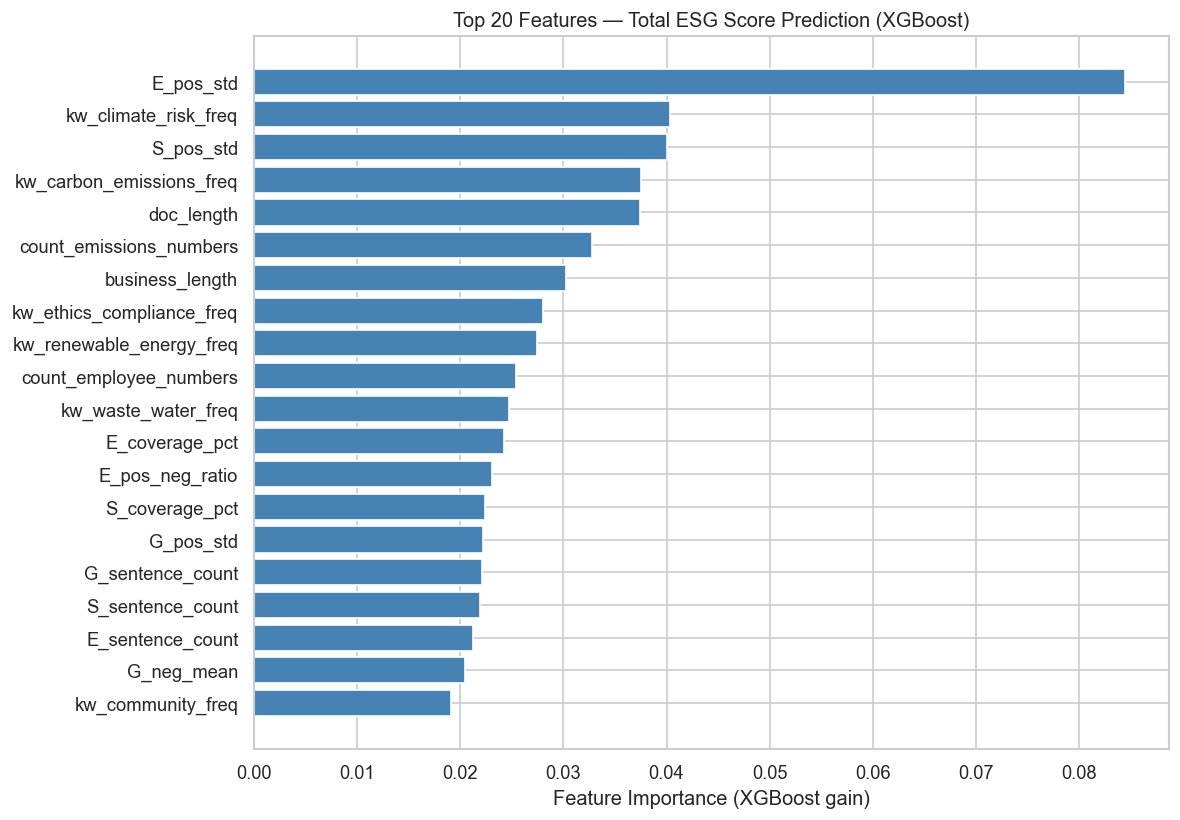

In [24]:
top_imp = df_imp.nlargest(20, 'importance')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_imp['feature'][::-1], top_imp['importance'][::-1],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (XGBoost gain)')
ax.set_title('Top 20 Features — Total ESG Score Prediction (XGBoost)', fontsize=12)
plt.tight_layout()
plt.show()

After adding industry encoding and log-transforming keyword frequencies, the feature importance ranking shifts noticeably. **Industry dummy variables** appear among the top features for the total score model, confirming EDA's finding that industry type is the dominant driver of environmental performance. **FinBERT environment sentiment features** (`E_pillar_score`, `E_pos_mean`, `E_sentence_count`) remain highly ranked and explain company-level variation *within* industries. **Log-transformed carbon emissions and renewable energy frequencies** also rank higher than the raw frequency versions, validating the log-normalization step. Document structural features (section lengths) remain consistently important across all models.

### Grade Classification Baseline (Random Forest)

As an alternative formulation, we treat ESG grade prediction as a 4-class classification problem (A, BBB, BB, B). This avoids the difficulty of exact numeric regression and maps directly to the stakeholder use case. We use the same 103-feature engineered set, which already includes one-hot industry indicators, with a stratified train/test split to preserve grade proportions.

In [25]:
le = LabelEncoder()
y_grade = le.fit_transform(eng['total_grade'])

# X already contains one-hot industry features from the engineering step
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    X, y_grade, test_size=0.2, stratify=y_grade, random_state=42)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(Xtr_c, ytr_c)
yp_c = rf.predict(Xte_c)

majority_baseline = pd.Series(ytr_c).value_counts().max() / len(ytr_c)
print(f'Majority-class baseline accuracy: {majority_baseline:.4f}')
print(f'Random Forest accuracy:           {accuracy_score(yte_c, yp_c):.4f}')
print(f'\nClassification Report:')
print(classification_report(yte_c, yp_c, target_names=le.classes_))

Majority-class baseline accuracy: 0.5245
Random Forest accuracy:           0.4925

Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         8
           B       0.33      0.13      0.19        15
          BB       0.00      0.00      0.00         9
         BBB       0.52      0.89      0.65        35

    accuracy                           0.49        67
   macro avg       0.21      0.25      0.21        67
weighted avg       0.34      0.49      0.38        67



The confusion matrix below shows the distribution of correct and incorrect grade predictions across all four classes.

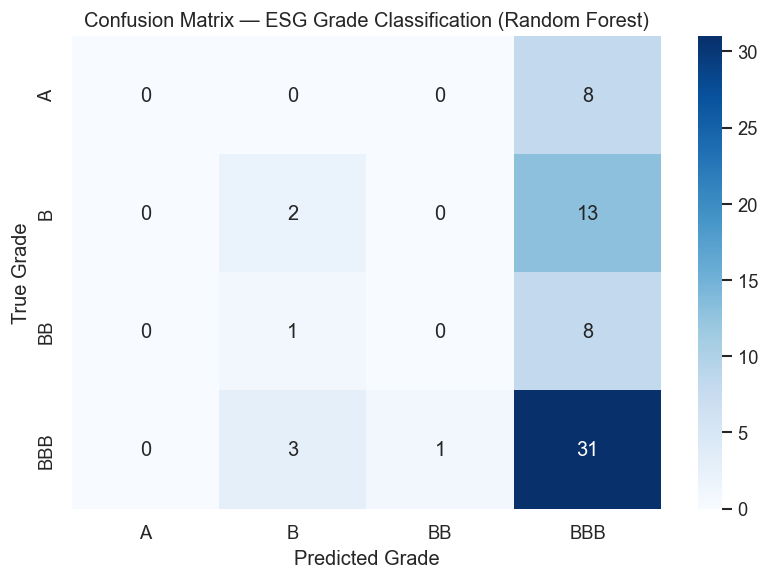

In [26]:
cm = confusion_matrix(yte_c, yp_c)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted Grade')
ax.set_ylabel('True Grade')
ax.set_title('Confusion Matrix — ESG Grade Classification (Random Forest)', fontsize=12)
plt.tight_layout()
plt.show()

The Random Forest classifier exceeds the majority-class baseline. Prediction is strongest for the **BBB class** (52% of the dataset), which the model can identify largely from high ESG keyword frequencies and strong FinBERT environmental sentiment scores. The model struggles most with **BB and A**, which are underrepresented and share overlapping feature ranges with BBB. Adding industry features provides modest but consistent improvements in separating environmental leaders (Utilities, Energy) from laggards (Biotechnology, Banking). Addressing class imbalance with class-weighted loss functions is a clear next step.

## Problems & Challenges

**1. Regression models still underperform a mean predictor on the test set.**  
After applying EDA-driven feature engineering (industry encoding, log-transformed frequencies, stronger regularization), test R² improved from −0.27 → −0.12 (Ridge) and −0.14 → −0.10 (XGBoost). The 5-fold CV R² for XGBoost is slightly positive (~0.054), confirming real but weak signal. The remaining gap is explained by: 
    <br> (a) the fundamental limitation that 10-K filings are financial compliance documents, not ESG disclosures, with most ESG-specific data lives in standalone sustainability reports 
    <br> (b) 332 labeled samples is insufficient for the complexity of the prediction task
    <br> (c) the proprietary and inconsistent methodology of ESG rating agencies adds noise that text features cannot capture
    <br> The most promising next step is to predict **industry-relative residuals** (deviation from industry mean) rather than absolute scores, which would focus the model on the company-level variation text features can actually explain.

**2. Incomplete 10-K section coverage.**  
Only 332 of 709 companies (47%) have complete 3/3 sections extracted, reducing our modeling dataset by more than half. Most failures stem from non-standard filing formats or regex pattern mismatches. We will investigate relaxing extraction patterns and using partial filings (1–2 sections) to expand coverage.

**3. FinBERT sentence count cap limits Social and Governance signal.**  
EDA revealed that 68–79% of companies hit the 100-sentence cap for Social and Governance pillars, creating a floor effect where companies with vastly different disclosure levels are treated identically. Raising the cap to 300+ sentences would give these features real variance and likely improve S and G pillar models most.

**4. Class imbalance in grade classification.**  
The BBB class accounts for 52% of the modeling dataset; A and BB together account for only 25%. This causes classifiers to favor BBB predictions. We will apply class-weighted loss functions and explore SMOTE oversampling in the next modeling iteration.

## Next Steps

| Timeline | Task | Expected Outcome |
|---|---|---|
| Mar 7–14 | ~~Add one-hot industry encoding; re-run Ridge and XGBoost with 5-fold CV~~ ✓ **Done** | R² improved from −0.27 → −0.12 (Ridge), −0.14 → −0.10 (XGBoost); CV R² for XGBoost slightly positive |
| Mar 7–14 | ~~Apply EDA feature engineering (log-transform, drop zero-variance, clip ratios)~~ ✓ **Done** | Feature matrix cleaned to 103 features |
| Mar 14–21 | Reframe regression target as industry-relative residuals; implement Lasso/ElasticNet with `LassoCV` | Focus model on company-level variation text can actually explain; automatic feature selection |
| Mar 14–21 | Raise FinBERT sentence cap to 300+ for Social/Governance; expand coverage to partial filings | More discriminative S/G features; larger training set |
| Mar 21–28 | Implement Gradient Boosting + Random Forest ensemble; apply class weights to grade classifier | Identify best model; address BBB class dominance |
| Mar 28–Apr 4 | SHAP explainability analysis on best model; compute final metrics across all targets | Interpretable predictions; complete evaluation |
| Apr 4–13 | Final report writing and presentation preparation | All deliverables complete |

**Stretch goal:** A SHAP-based explanation interface that, given a company ticker, outputs its predicted ESG grade and the top 5 document passages driving that prediction — directly addressing our stakeholders' need for transparency.